# Taxonomic signature of maturity

# Package

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.spatial import distance
from skbio.diversity import beta_diversity
from skbio.stats.ordination import pcoa
from sklearn.decomposition import PCA
from scipy.stats import ttest_1samp
import math
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import tukey_hsd
from scipy.stats import wilcoxon, bartlett
import scipy
import scipy.stats as stats
from scipy.stats import f_oneway
from scipy import ndimage
import statsmodels
import seaborn as sns
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.graphics.factorplots import interaction_plot
import matplotlib.pyplot as plt
from statsmodels.stats.oneway import anova_oneway
from scipy.stats import friedmanchisquare
from scipy import stats
from skbio.diversity.alpha import shannon
import matplotlib.patches as patches
from skbio.diversity import alpha_diversity
from statannotations.Annotator import Annotator
from skbio.stats.distance import permanova
from skbio import DistanceMatrix
from itertools import combinations
from skbio.stats.distance import permdisp



# Method

## Data Import
- Import diversity results file from QIIME2 outputs.
    - Shannon index: QIIME2 `diversity` metrics use and export to csv file `shannon_vector.qza`
    - Bray curtis: QIIME2 `diversity` metrics use and export to csv file `bray_curtis_pcoa_results.qza`
    - PERMANOVA: QIIME2 `diversity` metrics use and export to csv file `bray_curtis_distance_matrix.qza`


In [ ]:

meta_path = "data/pre_metadata.tsv"
mmi_path = 'data/mmi.tsv'
shannon = 'data/2_preprocessed/diversity/shannon_table.tsv'
faith_pd = 'data/2_preprocessed/diversity/faith_pd.tsv'
obser = 'data/2_preprocessed/diversity/observed_feature.tsv'
simp = 'data/2_preprocessed/diversity/simpson.tsv'
even = 'data/2_preprocessed/diversity/evenness.tsv'
meta = pd.read_csv(meta_path, sep='\t').set_index('#SampleID')
mmi = pd.read_csv(mmi_path, sep='\t').set_index('#SampleID')
shannon = pd.read_csv(shannon, sep='\t').set_index('#SampleID')
faith = pd.read_csv(faith_pd, sep='\t').set_index('#SampleID')
observed = pd.read_csv(obser, sep='\t').set_index('#SampleID')
simpson = pd.read_csv(simp, sep='\t').set_index('#SampleID')
evenness = pd.read_csv(even, sep='\t').set_index('#SampleID')




m = mmi



In [4]:
mmi.head(2)

,Unnamed: 0,real_age,mmi,real_year,pred_year,Months,host_sex,Host_disease,location_disease,mean_age,Separation,Network,Group
#SampleID,,,,,,,,,,,,,
SRR23478195,0,18.0,67.06,1.0,5.09,18.0,female,Control,Control(IT),50.83,mmihigh,mmihigh,mmihigh
SRR23478196,1,18.0,45.70,1.0,3.31,18.0,male,Control,Control(IT),50.83,mmilow,mmilow,mmilow


- shannon index file merge by mmi results file

In [5]:
alpha_s = shannon.merge(mmi,left_index=True, right_index=True)
alpha_f = faith.merge(alpha_s,left_index=True, right_index=True)
alpha_o = observed.merge(alpha_f,left_index=True, right_index=True)
alpha_si = simpson.merge(alpha_o, left_index=True, right_index=True)
alpha_df = evenness.merge(alpha_si, left_index=True, right_index=True)

alpha_df["Group"] = alpha_df.apply(
    lambda row: row["Separation"] if row["Host_disease"] == "Control" else row["Group"],
    axis=1
)

alpha_df = alpha_df.rename(columns={"shannon_entropy":"shannon"}).copy()



In [6]:
alpha_df.head(-5)

,pielou_evenness,simpsons,observed_features,faith_pd,shannon,Unnamed: 0,real_age,mmi,real_year,pred_year,Months,host_sex,Host_disease,location_disease,mean_age,Separation,Network,Group
#SampleID,,,,,,,,,,,,,,,,,,
SRR23478191,0.676959,0.911857,107,10.271827,4.563695,70,138.0,60.84,11.0,4.57,138.0,female,Control,Control(IT),109.76,mmilow,mmilow,mmilow
SRR23478195,0.193163,0.243973,52,8.149965,1.101117,0,18.0,67.06,1.0,5.09,18.0,female,Control,Control(IT),50.83,mmihigh,mmihigh,mmihigh
SRR23478196,0.715996,0.951896,121,12.878318,4.953880,1,18.0,45.70,1.0,3.31,18.0,male,Control,Control(IT),50.83,mmilow,mmilow,mmilow
SRR23478197,0.618990,0.831757,57,7.907863,3.610500,2,18.0,39.73,1.0,2.81,18.0,female,Control,Control(IT),50.83,mmilow,mmilow,mmilow
SRR23478198,0.690009,0.894017,71,9.236993,4.243378,3,30.0,57.06,2.0,4.25,30.0,male,Control,Control(IT),56.42,mmihigh,mmihigh,mmihigh
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SRR29856091,0.637092,0.875586,123,11.776509,4.423021,107,126.0,89.07,10.0,6.92,126.0,male,PIBD,PIBD(IT),125.10,mmilow,PIBD,PIBD
SRR29856092,0.718526,0.910822,81,9.558273,4.555349,108,174.0,70.63,14.0,5.39,174.0,female,PIBD,PIBD(IT),100.24,mmilow,PIBD,PIBD
SRR29856093,0.251066,0.346555,61,8.311548,1.489007,109,114.0,77.25,9.0,5.94,114.0,female,PIBD,PIBD(IT),95.75,mmilow,PIBD,PIBD


- bray curtis distance file import and preprocessing

In [ ]:
path = "data/2_preprocessed/diversity/bc.txt"

with open(path, "r") as f:
    lines = f.readlines()

site_start = None
for i, line in enumerate(lines):
    if line.startswith("Site"):
        site_start = i
        break

if site_start is None:
    raise ValueError("No 'Site' section found")


site_lines = lines[site_start + 1 :]


site_lines = [ln.strip() for ln in site_lines if ln.strip()]

# Split and DataFrame
rows = [ln.split("\t") for ln in site_lines]

n_pc = len(rows[0]) - 1
cols = ["SampleID"] + [f"PC{i}" for i in range(1, n_pc + 1)]

pcoa_df = pd.DataFrame(rows, columns=cols)

# excluded by SampleID
for c in cols[1:]:
    pcoa_df[c] = pd.to_numeric(pcoa_df[c], errors="coerce")

    
pcoa_df.rename(columns={'SampleID':'#SampleID'}, inplace=True)
pcoa_df = pcoa_df.set_index('#SampleID')


In [8]:
beta_df = pcoa_df[["PC1","PC2"]].merge(alpha_df, left_index=True, right_index=True)

In [9]:
with open(path, "r") as f:
    lines = f.readlines()

eig_start = None
for i, line in enumerate(lines):
    if line.startswith("Eigvals"):
        eig_start = i
        break

if eig_start is None:
    raise ValueError("No 'Eigvals' section found")

eigvals = [float(x) for x in lines[eig_start + 1].strip().split("\t")]
explained = [x / sum(eigvals) * 100 for x in eigvals]

pc1_var = explained[0]
pc2_var = explained[1]

## Palette Setting

In [10]:
palette = {                     # ver 1   # ver 2 # ver 3
    "mmihigh": "#326a81a0", #20854ea0 #326a81a0 #9fbcca
    "mmilow": "#9fbccaa0", #326a81a0 #9fbcca #a8ddb5
    "ulcerative colitis": "#fddbc7a0", #9fbcca #20854ea0 #ffeda0
    "crohn's disease": "#ef8a62", #7876b1c0 #7876b1c0 #feb24c
    "UC": "#fddbc7a0",
    "PIBD": "#ef8a62",
    "CD": "#ef8a62"
}
plt.rcParams['font.size'] = 7
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42
# affects whiskers, medians, caps (all Line2D)
plt.rcParams['lines.linewidth'] = 0.6


In [11]:
alpha_df.head(2)

,pielou_evenness,simpsons,observed_features,faith_pd,shannon,Unnamed: 0,real_age,mmi,real_year,pred_year,Months,host_sex,Host_disease,location_disease,mean_age,Separation,Network,Group
#SampleID,,,,,,,,,,,,,,,,,,
SRR23478191,0.676959,0.911857,107,10.271827,4.563695,70,138.0,60.84,11.0,4.57,138.0,female,Control,Control(IT),109.76,mmilow,mmilow,mmilow
SRR23478195,0.193163,0.243973,52,8.149965,1.101117,0,18.0,67.06,1.0,5.09,18.0,female,Control,Control(IT),50.83,mmihigh,mmihigh,mmihigh


# 2. Alpha Diversity

- Shannon index figure
- Mann-whitney u test use group significant different test 

### Shannon

/tmp/ipykernel_3957868/1493552401.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_con = sns.boxplot(data=alpha_df_control, x="Group", y="shannon", palette=palette)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

mmihigh vs. mmilow: Mann-Whitney-Wilcoxon test two-sided, P_val:1.072e-01 U_stat=1.318e+03


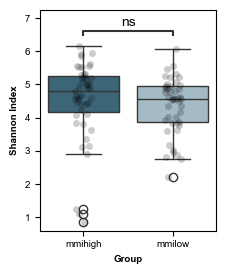

/tmp/ipykernel_3957868/1493552401.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_all = sns.boxplot(data=alpha_df, x="Group", y="shannon", palette=palette, order=order)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

mmihigh vs. mmilow: Mann-Whitney-Wilcoxon test two-sided, P_val:1.072e-01 U_stat=1.318e+03
mmilow vs. PIBD: Mann-Whitney-Wilcoxon test two-sided, P_val:9.825e-01 U_stat=1.148e+03
mmihigh vs. PIBD: Mann-Whitney-Wilcoxon test two-sided, P_val:9.913e-02 U_stat=1.377e+03


,count,mean,std,min,25%,50%,75%,max
Group,,,,,,,,
PIBD,49.0,4.305335,0.978961,1.435538,4.097842,4.555349,4.982707,5.714967
mmihigh,47.0,4.530045,1.188173,0.859391,4.179761,4.803425,5.250210,6.152823
mmilow,47.0,4.371026,0.841457,2.198275,3.861386,4.563695,4.941304,6.078283


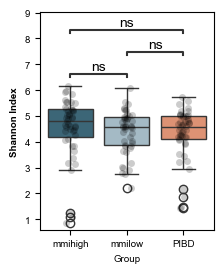

In [12]:
alpha_df_control = alpha_df[alpha_df["Host_disease"] == "Control"]

alpha_df_control = alpha_df_control.sort_values(by = ['Group'], ascending=True) ## if linear separation? 'Group'
order = ["mmihigh", "mmilow", "PIBD"]
# Visualization

fig = plt.figure(figsize=(3.75, 2.75))
ax = fig.add_subplot(111)
ax_con = sns.boxplot(data=alpha_df_control, x="Group", y="shannon", palette=palette)
sns.stripplot(data=alpha_df_control, x="Group", y="shannon",
              color="black", alpha=0.2, jitter=True, )
pairs_con = [
    ("mmihigh", "mmilow")
]

annot_con = Annotator(ax_con, pairs_con, data=alpha_df_control, x="Group", y="shannon")
annot_con.configure(test="Mann-Whitney", text_format="star", fontsize=10, loc="inside")
annot_con.apply_and_annotate()

#t-test_ind, t-test_welch, t-test_paired, Mann-Whitney, Mann-Whitney-gt, Mann-Whitney-ls, Levene, Wilcoxon, Kruskal, Brunner-Munzel.

ax.set_xlabel("Group", fontweight='bold')
ax.set_ylabel("Shannon Index", fontweight='bold')
ax.set_box_aspect(1.25)
fig.tight_layout()
fig.savefig('figure/3_diversity/shannon/control_shannon.pdf', dpi=300)
plt.show()



fig = plt.figure(figsize=(3.75, 2.75))
ax = fig.add_subplot(111)
ax_all = sns.boxplot(data=alpha_df, x="Group", y="shannon", palette=palette, order=order)
sns.stripplot(data=alpha_df, x="Group", y="shannon",
              color="black", alpha=0.2, jitter=True, order=order)
pairs = [
    ("mmihigh", "mmilow"),
    ("mmihigh", "PIBD"),
    ("mmilow", "PIBD"),
]

annot = Annotator(ax_all, pairs, data=alpha_df, x="Group", y="shannon", order=order)
annot.configure(test="Mann-Whitney", text_format="star", fontsize=10,loc="inside",hide_non_significant=False)
annot.apply_and_annotate()

#Mann-Whitney, Mann-Whitney-gt, Mann-Whitney-ls, Levene, Wilcoxon, Kruskal, Brunner-Munzel.
ax.set_ylabel("Shannon Index", fontweight='bold')
ax.set_box_aspect(1.25)
fig.tight_layout()
fig.savefig('figure/3_diversity//shannon/all_shannon.pdf', dpi=300)
fig.show()

alpha_df.groupby("Group")["shannon"].describe()

### faith_pd

/tmp/ipykernel_3957868/110104287.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_con = sns.boxplot(data=alpha_df_control, x="Group", y="faith_pd", palette=palette)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

mmihigh vs. mmilow: Mann-Whitney-Wilcoxon test two-sided, P_val:9.287e-03 U_stat=1.449e+03


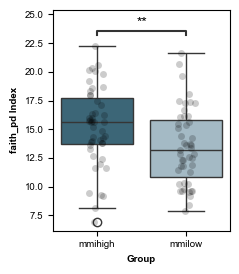

/tmp/ipykernel_3957868/110104287.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_all = sns.boxplot(data=alpha_df, x="Group", y="faith_pd", palette=palette, order=order)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

mmihigh vs. mmilow: Mann-Whitney-Wilcoxon test two-sided, P_val:9.287e-03 U_stat=1.449e+03
mmilow vs. PIBD: Mann-Whitney-Wilcoxon test two-sided, P_val:5.478e-01 U_stat=1.234e+03
mmihigh vs. PIBD: Mann-Whitney-Wilcoxon test two-sided, P_val:2.187e-03 U_stat=1.570e+03


,count,mean,std,min,25%,50%,75%,max
Group,,,,,,,,
PIBD,49.0,13.008441,3.567672,4.439307,10.485494,12.684174,15.124541,20.938443
mmihigh,47.0,15.238752,3.442393,6.925433,13.723273,15.602982,17.713192,22.234839
mmilow,47.0,13.487741,3.300903,7.907863,10.805823,13.177672,15.830714,21.612608


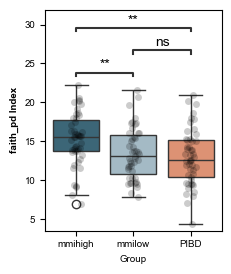

In [13]:
alpha_df_control = alpha_df[alpha_df["Host_disease"] == "Control"]

alpha_df_control = alpha_df_control.sort_values(by = ['Group'], ascending=True)
order = ["mmihigh", "mmilow", "PIBD"]
# Visualization

fig = plt.figure(figsize=(3.75, 2.75))
ax = fig.add_subplot(111)
ax_con = sns.boxplot(data=alpha_df_control, x="Group", y="faith_pd", palette=palette)
sns.stripplot(data=alpha_df_control, x="Group", y="faith_pd",
              color="black", alpha=0.2, jitter=True, )
pairs_con = [
    ("mmihigh", "mmilow")
]

annot_con = Annotator(ax_con, pairs_con, data=alpha_df_control, x="Group", y="faith_pd")
annot_con.configure(test="Mann-Whitney", text_format="star", fontsize=10, loc="inside")
annot_con.apply_and_annotate()

#t-test_ind, t-test_welch, t-test_paired, Mann-Whitney, Mann-Whitney-gt, Mann-Whitney-ls, Levene, Wilcoxon, Kruskal, Brunner-Munzel.

ax.set_xlabel("Group", fontweight='bold')
ax.set_ylabel("faith_pd Index", fontweight='bold')
ax.set_box_aspect(1.25)
fig.tight_layout()
fig.savefig('figure/3_diversity/faith_pd/control_faith_pd.pdf', dpi=300)
plt.show()



fig = plt.figure(figsize=(3.75, 2.75))
ax = fig.add_subplot(111)
ax_all = sns.boxplot(data=alpha_df, x="Group", y="faith_pd", palette=palette, order=order)
sns.stripplot(data=alpha_df, x="Group", y="faith_pd",
              color="black", alpha=0.2, jitter=True, order=order)
pairs = [
    ("mmihigh", "mmilow"),
    ("mmihigh", "PIBD"),
    ("mmilow", "PIBD")
]

annot = Annotator(ax_all, pairs, data=alpha_df, x="Group", y="faith_pd", order=order)
annot.configure(test="Mann-Whitney", text_format="star", fontsize=10,loc="inside",hide_non_significant=False)
annot.apply_and_annotate()


ax.set_ylabel("faith_pd Index", fontweight='bold')
ax.set_box_aspect(1.25)
fig.tight_layout()
fig.savefig('figure/3_diversity/faith_pd/all_faith_pd.pdf', dpi=300)
fig.show()


alpha_df.groupby("Group")["faith_pd"].describe()

### simpson

/tmp/ipykernel_3957868/2906812176.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_con = sns.boxplot(data=alpha_df_control, x="Group", y="simpsons", palette=palette)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

mmihigh vs. mmilow: Mann-Whitney-Wilcoxon test two-sided, P_val:5.861e-01 U_stat=1.177e+03


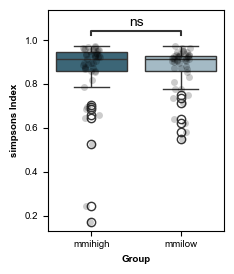

/tmp/ipykernel_3957868/2906812176.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_all = sns.boxplot(data=alpha_df, x="Group", y="simpsons", palette=palette, order=order)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

mmihigh vs. mmilow: Mann-Whitney-Wilcoxon test two-sided, P_val:5.861e-01 U_stat=1.177e+03
mmilow vs. PIBD: Mann-Whitney-Wilcoxon test two-sided, P_val:8.317e-01 U_stat=1.181e+03
mmihigh vs. PIBD: Mann-Whitney-Wilcoxon test two-sided, P_val:5.527e-01 U_stat=1.233e+03


,count,mean,std,min,25%,50%,75%,max
Group,,,,,,,,
PIBD,49.0,0.864729,0.125960,0.346555,0.864858,0.900165,0.936957,0.958625
mmihigh,47.0,0.851794,0.169657,0.171390,0.858944,0.914203,0.945900,0.971931
mmilow,47.0,0.869394,0.103352,0.551188,0.860938,0.911857,0.929244,0.971146


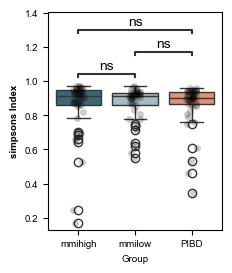

In [14]:
alpha_df_control = alpha_df[alpha_df["Host_disease"] == "Control"]

alpha_df_control = alpha_df_control.sort_values(by = ['Group'], ascending=True)
order = ["mmihigh", "mmilow", "PIBD"]
# Visualization

fig = plt.figure(figsize=(3.75, 2.75))
ax = fig.add_subplot(111)
ax_con = sns.boxplot(data=alpha_df_control, x="Group", y="simpsons", palette=palette)
sns.stripplot(data=alpha_df_control, x="Group", y="simpsons",
              color="black", alpha=0.2, jitter=True, )
pairs_con = [
    ("mmihigh", "mmilow")
]

annot_con = Annotator(ax_con, pairs_con, data=alpha_df_control, x="Group", y="simpsons")
annot_con.configure(test="Mann-Whitney", text_format="star", fontsize=10, loc="inside")
annot_con.apply_and_annotate()

#t-test_ind, t-test_welch, t-test_paired, Mann-Whitney, Mann-Whitney-gt, Mann-Whitney-ls, Levene, Wilcoxon, Kruskal, Brunner-Munzel.

ax.set_xlabel("Group", fontweight='bold')
ax.set_ylabel("simpsons Index", fontweight='bold')
ax.set_box_aspect(1.25)
fig.tight_layout()
fig.savefig('figure/3_diversity/simpson/control_simpson.pdf', dpi=300)
plt.show()



fig = plt.figure(figsize=(3.75, 2.75))
ax = fig.add_subplot(111)
ax_all = sns.boxplot(data=alpha_df, x="Group", y="simpsons", palette=palette, order=order)
sns.stripplot(data=alpha_df, x="Group", y="simpsons",
              color="black", alpha=0.2, jitter=True, order=order)
pairs = [
    ("mmihigh", "mmilow"),
    ("mmihigh", "PIBD"),
    ("mmilow", "PIBD")
]

annot = Annotator(ax_all, pairs, data=alpha_df, x="Group", y="simpsons", order=order)
annot.configure(test="Mann-Whitney", text_format="star", fontsize=10,loc="inside",hide_non_significant=False)
annot.apply_and_annotate()


ax.set_ylabel("simpsons Index", fontweight='bold')
ax.set_box_aspect(1.25)
fig.tight_layout()
fig.savefig('figure/3_diversity/simpson/all_simpson.pdf', dpi=300)
fig.show()


alpha_df.groupby("Group")["simpsons"].describe()

### pielou_evenness

/tmp/ipykernel_3957868/2757563172.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_con = sns.boxplot(data=alpha_df_control, x="Group", y="pielou_evenness", palette=palette)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

mmihigh vs. mmilow: Mann-Whitney-Wilcoxon test two-sided, P_val:9.518e-01 U_stat=1.096e+03


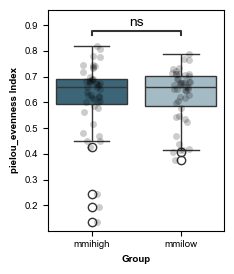

/tmp/ipykernel_3957868/2757563172.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_all = sns.boxplot(data=alpha_df, x="Group", y="pielou_evenness", palette=palette, order=order)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

mmihigh vs. mmilow: Mann-Whitney-Wilcoxon test two-sided, P_val:9.518e-01 U_stat=1.096e+03
mmilow vs. PIBD: Mann-Whitney-Wilcoxon test two-sided, P_val:8.604e-01 U_stat=1.176e+03
mmihigh vs. PIBD: Mann-Whitney-Wilcoxon test two-sided, P_val:9.883e-01 U_stat=1.149e+03


,count,mean,std,min,25%,50%,75%,max
Group,,,,,,,,
PIBD,49.0,0.622813,0.114974,0.251066,0.581629,0.661337,0.700596,0.767759
mmihigh,47.0,0.617923,0.145246,0.135938,0.594424,0.660481,0.690876,0.818299
mmilow,47.0,0.628629,0.105803,0.376876,0.587358,0.661522,0.704182,0.786535


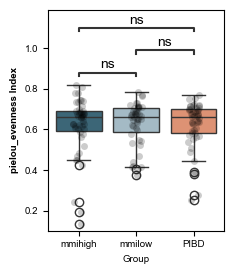

In [15]:
alpha_df_control = alpha_df[alpha_df["Host_disease"] == "Control"]

alpha_df_control = alpha_df_control.sort_values(by = ['Group'], ascending=True)
order = ["mmihigh", "mmilow", "PIBD"]
# Visualization

fig = plt.figure(figsize=(3.75, 2.75))
ax = fig.add_subplot(111)
ax_con = sns.boxplot(data=alpha_df_control, x="Group", y="pielou_evenness", palette=palette)
sns.stripplot(data=alpha_df_control, x="Group", y="pielou_evenness",
              color="black", alpha=0.2, jitter=True, )
pairs_con = [
    ("mmihigh", "mmilow")
]

annot_con = Annotator(ax_con, pairs_con, data=alpha_df_control, x="Group", y="pielou_evenness")
annot_con.configure(test="Mann-Whitney", text_format="star", fontsize=10, loc="inside")
annot_con.apply_and_annotate()

#t-test_ind, t-test_welch, t-test_paired, Mann-Whitney, Mann-Whitney-gt, Mann-Whitney-ls, Levene, Wilcoxon, Kruskal, Brunner-Munzel.

ax.set_xlabel("Group", fontweight='bold')
ax.set_ylabel("pielou_evenness Index", fontweight='bold')
ax.set_box_aspect(1.25)
fig.tight_layout()
fig.savefig('figure/3_diversity/evenness/control_pielou_evenness.pdf', dpi=300)
plt.show()



fig = plt.figure(figsize=(3.75, 2.75))
ax = fig.add_subplot(111)
ax_all = sns.boxplot(data=alpha_df, x="Group", y="pielou_evenness", palette=palette, order=order)
sns.stripplot(data=alpha_df, x="Group", y="pielou_evenness",
              color="black", alpha=0.2, jitter=True, order=order)
pairs = [
    ("mmihigh", "mmilow"),
    ("mmihigh", "PIBD"),
    ("mmilow", "PIBD")
]

annot = Annotator(ax_all, pairs, data=alpha_df, x="Group", y="pielou_evenness", order=order)
annot.configure(test="Mann-Whitney", text_format="star", fontsize=10,loc="inside",hide_non_significant=False)
annot.apply_and_annotate()


ax.set_ylabel("pielou_evenness Index", fontweight='bold')
ax.set_box_aspect(1.25)
fig.tight_layout()
fig.savefig('figure/3_diversity/evenness/all_pielou_evenness.pdf', dpi=300)
fig.show()


alpha_df.groupby("Group")["pielou_evenness"].describe()

### observed_features

/tmp/ipykernel_3957868/396272629.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_con = sns.boxplot(data=alpha_df_control, x="Group", y="observed_features", palette=palette)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

mmihigh vs. mmilow: Mann-Whitney-Wilcoxon test two-sided, P_val:7.134e-04 U_stat=1.552e+03


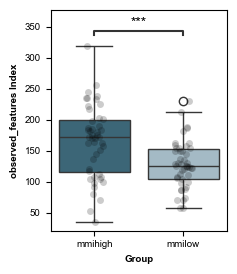

/tmp/ipykernel_3957868/396272629.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_all = sns.boxplot(data=alpha_df, x="Group", y="observed_features", palette=palette, order=order)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

mmihigh vs. mmilow: Mann-Whitney-Wilcoxon test two-sided, P_val:7.134e-04 U_stat=1.552e+03
mmilow vs. PIBD: Mann-Whitney-Wilcoxon test two-sided, P_val:8.088e-01 U_stat=1.185e+03
mmihigh vs. PIBD: Mann-Whitney-Wilcoxon test two-sided, P_val:7.371e-04 U_stat=1.612e+03


,count,mean,std,min,25%,50%,75%,max
Group,,,,,,,,
PIBD,49.0,125.204082,47.011071,28.0,88.0,125.0,153.0,242.0
mmihigh,47.0,164.617021,58.489893,35.0,115.5,172.0,199.5,319.0
mmilow,47.0,128.063830,37.863832,57.0,105.0,126.0,152.5,231.0


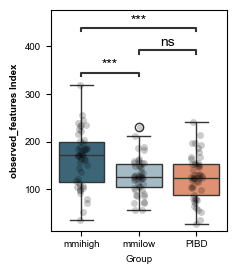

In [16]:
alpha_df_control = alpha_df[alpha_df["Host_disease"] == "Control"]

alpha_df_control = alpha_df_control.sort_values(by = ['Group'], ascending=True)
order = ["mmihigh", "mmilow", "PIBD"]
# Visualization

fig = plt.figure(figsize=(3.75, 2.75))
ax = fig.add_subplot(111)
ax_con = sns.boxplot(data=alpha_df_control, x="Group", y="observed_features", palette=palette)
sns.stripplot(data=alpha_df_control, x="Group", y="observed_features",
              color="black", alpha=0.2, jitter=True, )
pairs_con = [
    ("mmihigh", "mmilow")
]

annot_con = Annotator(ax_con, pairs_con, data=alpha_df_control, x="Group", y="observed_features")
annot_con.configure(test="Mann-Whitney", text_format="star", fontsize=10, loc="inside")
annot_con.apply_and_annotate()

#t-test_ind, t-test_welch, t-test_paired, Mann-Whitney, Mann-Whitney-gt, Mann-Whitney-ls, Levene, Wilcoxon, Kruskal, Brunner-Munzel.

ax.set_xlabel("Group", fontweight='bold')
ax.set_ylabel("observed_features Index", fontweight='bold')
ax.set_box_aspect(1.25)
fig.tight_layout()
fig.savefig('figure/3_diversity/observed/control_observed_features.pdf', dpi=300)
plt.show()



fig = plt.figure(figsize=(3.75, 2.75))
ax = fig.add_subplot(111)
ax_all = sns.boxplot(data=alpha_df, x="Group", y="observed_features", palette=palette, order=order)
sns.stripplot(data=alpha_df, x="Group", y="observed_features",
              color="black", alpha=0.2, jitter=True, order=order)
pairs = [
    ("mmihigh", "mmilow"),
    ("mmihigh", "PIBD"),
    ("mmilow", "PIBD")
]

annot = Annotator(ax_all, pairs, data=alpha_df, x="Group", y="observed_features", order=order)
annot.configure(test="Mann-Whitney", text_format="star", fontsize=10,loc="inside",hide_non_significant=False)
annot.apply_and_annotate()


ax.set_ylabel("observed_features Index", fontweight='bold')
ax.set_box_aspect(1.25)
fig.tight_layout()
fig.savefig('figure/3_diversity/observed/all_observed_features.pdf', dpi=300)
fig.show()


alpha_df.groupby("Group")["observed_features"].describe()

# 3. Beta Diversity

- Bray curtis distance PCOA Plotting
- PERMANOVA use by significant difference test

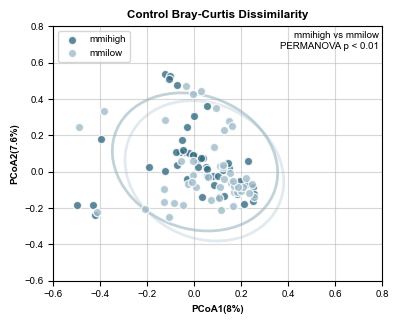

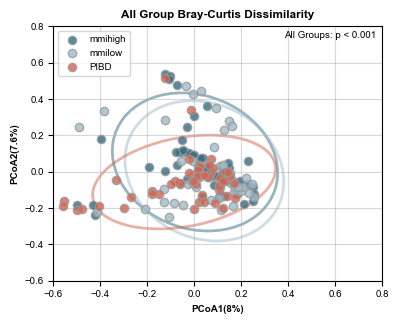

In [ ]:
dm_path = "data/2_preprocessed/diversity/distance-matrix.tsv"
distance_matrix = DistanceMatrix.read(dm_path)


def plot_confidence_ellipse(x, y, ax, n_std=2.0, edgecolor='black', **kwargs):
    if x.size != y.size:
        raise ValueError("different")

    cov = np.cov(x, y)
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]

    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(vals)

    ellipse = patches.Ellipse(
        xy=(np.mean(x), np.mean(y)),
        width=width, height=height,
        angle=theta, edgecolor=edgecolor, facecolor='none', lw=2, **kwargs
    )
    ax.add_patch(ellipse)
    return ellipse

def permanova_r2(result, n_samples, n_Groups):
    F = result["test statistic"]
    return (F * (n_Groups - 1)) / (F * (n_Groups - 1) + (n_samples - n_Groups))

metadata = beta_df[['Network', 'Group']].copy()


fig = plt.figure(figsize=(4, 3.25))
ax = fig.add_subplot(111)

for separation in (['mmihigh', 'mmilow']):
    subset = beta_df[beta_df['Group'] == separation]
    color = palette[separation]
    plt.scatter(subset['PC1'], subset['PC2'], label=separation, color=color, alpha=0.8, edgecolor='white', zorder=10)

    plot_confidence_ellipse(
        subset['PC1'].values, subset['PC2'].values,
        ax, n_std=2.0, edgecolor=color, alpha=0.3
    )

# PERMANOVA for Control
control_samples = metadata[metadata['Group'].isin(['mmihigh', 'mmilow'])].index.tolist()
control_samples = [s for s in control_samples if s in distance_matrix.ids]

if len(control_samples) > 0:
    control_dm = distance_matrix.filter(control_samples)
    control_Groups = metadata.loc[control_samples, 'Group']
    
    perm_result = permanova(control_dm, control_Groups, permutations=999)
    p_value = perm_result['p-value']

    r2 = permanova_r2(perm_result, len(control_samples), control_Groups.nunique())
    
    # P-value 
    if p_value < 0.001:
        sig = "p < 0.001"
    elif p_value < 0.01:
        sig = "p < 0.01"
    elif p_value < 0.05:
        sig = "p < 0.05"
    else:
        sig = "ns"
    
    p_text = f"mmihigh vs mmilow\nPERMANOVA {sig}"
    
    ax.text(0.99, 0.98, p_text, 
             transform=ax.transAxes,
             fontsize=7,
             verticalalignment='top',
             horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0))

ax.set_xlabel(f'PCoA1(8%)', fontweight='bold') ## 0.13998587902363593 (proportion explained)
ax.set_ylabel(f'PCoA2(7.6%)', fontweight='bold') ## 0.0997630549395696 (proportion explained)
ax.grid(True, alpha=0.5)
ax.set_xlim(-0.6, 0.8)
ax.set_ylim(-0.6, 0.8)
ax.set_title('Control Bray-Curtis Dissimilarity', fontweight='bold')
ax.legend(loc='upper left', bbox_to_anchor=(0,1))
fig.tight_layout()
fig.savefig('figure/3_diversity/pcoa/control_bc_perma.pdf', dpi=300)
fig.show()


# 2. All Groups plot with pairwise PERMANOVA

fig = plt.figure(figsize=(4, 3.25))
ax = fig.add_subplot(111)

beta_color = {
    'mmihigh': "#326a81a0",
    'mmilow': "#9fbccaa0",
    'PIBD':'#d6604da0',
    'CD':'#d6604da0'
}

for Group in (['mmihigh', 'mmilow', 'PIBD']):
    subset = beta_df[beta_df['Group'] == Group]
    color = beta_color[Group]
    ## edgecolor = 'black' or pibd color another use
    plt.scatter(subset['PC1'], subset['PC2'], label=Group, color=color, alpha=0.8, edgecolor='#999999', zorder=10) 

    plot_confidence_ellipse(
        subset['PC1'].values, subset['PC2'].values,
        ax, n_std=2.0, edgecolor=color, alpha=0.5
    )

# Pairwise PERMANOVA
all_samples = metadata[metadata['Group'].isin(['mmihigh', 'mmilow', 'PIBD'])].index.tolist()
all_samples = [s for s in all_samples if s in distance_matrix.ids]

if len(all_samples) > 0:
    all_dm = distance_matrix.filter(all_samples)
    all_Groups = metadata.loc[all_samples, 'Group']
    
    perm_result = permanova(all_dm, all_Groups, permutations=999)
    p_value = perm_result['p-value']
    
    # P-value 텍스트 추가
    if p_value < 0.001:
        p_text = "All Groups: p < 0.001***"
    elif p_value < 0.01:
        p_text = f"All Groups: p < {p_value:.3f}"
    elif p_value < 0.05:
        p_text = f"All Groups: p < {p_value:.3f}"
    else:
        p_text = f"All Groups: p < {p_value:.3f} (ns)"
    
    fig.text(0.98, 0.98, p_text, 
             transform=ax.transAxes,
             fontsize=7,
             verticalalignment='top',
             horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0))


ax.set_xlabel(f'PCoA1(8%)', fontweight='bold') ## 0.8 (proportion explained)
ax.set_ylabel(f'PCoA2(7.6%)', fontweight='bold') ## 0.76 (proportion explained)
ax.set_xlim(-0.6, 0.8)
ax.set_ylim(-0.6, 0.8)
ax.grid(True, alpha=0.5)
ax.set_title('All Group Bray-Curtis Dissimilarity', fontweight='bold')
ax.legend(bbox_to_anchor = (0,1), loc='upper left')
fig.tight_layout()
fig.savefig('figure/3_diversity/pcoa/all_bc_perma.pdf', dpi=300)
fig.show()